# From association to longitudinal TMLE with the TWINS data

This notebook is an end-to-end causal analysis with `cleverly`. It starts with a crude contrast, builds g-computation and inverse-probability weighting by hand, then moves through every point-treatment TMLE method that is appropriate for this question: ordinary TMLE, stacked and fold-evaluated CV-TMLE, collaborative TMLE (C-TMLE), doubly robust-inference TMLE (DR-TMLE), and TMLE with a Super Learner. It finishes with diagnostics, sensitivity analysis, multiple estimands, and a two-time longitudinal TMLE (LTMLE) extension.

The goal is to learn the workflow and the estimators, **not to make a clinical claim**. Low birth weight is a post-conception state rather than a directly assignable treatment, and the public data do not contain every common cause of birth weight and mortality. Read causal estimates below as illustrations conditional on the stated identification assumptions.

By the end, you should be able to:

- distinguish an observed association from an identified causal estimand;
- explain how g-computation, IPW, and TMLE use the outcome and treatment mechanisms;
- choose among ordinary TMLE, CV-TMLE, C-TMLE, and DR-TMLE;
- inspect support, score equations, nuisance fits, and omitted-variable sensitivity; and
- encode a time-ordered treatment question for LTMLE.

## 1. Setup and reproducibility

Run this notebook from the project environment (`uv sync --extra dev`). The data URLs are pinned to the CEVAE repository commit used when this notebook was published. The analysis samples twin pairs, not individual children, so both twins are always retained together.

In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import cleverly
from cleverly import (
    ATC,
    ATE,
    ATT,
    CausalStudy,
    CollaborativeTMLEMethod,
    CounterfactualMean,
    CrossFitting,
    DRTMLEMethod,
    Inference,
    LongitudinalTreatment,
    ModelSpec,
    OddsRatio,
    PointTreatment,
    PopulationAttributableFraction,
    PopulationAttributableRisk,
    RegimeContrast,
    RiskRatio,
    Runtime,
    SuperLearner,
    TMLEMethod,
)

SEED = 2026
N_PAIRS = 6_000
pd.set_option("display.max_columns", 20)
pd.set_option("display.precision", 4)
warnings.filterwarnings("ignore", category=UserWarning)

## 2. Load and understand TWINS

The [CEVAE TWINS directory](https://github.com/AMLab-Amsterdam/CEVAE/tree/9081f863e24ce21bd34c8d6a41bf0edc7d1b65dd/datasets/TWINS) derives same-sex US twin pairs born in 1989–1991 from linked birth and infant-death records. Its three files contain pair covariates (`X`), both birth weights (`T`), and both three-year mortality outcomes (`Y`). The original README points to the NBER linked birth/infant-death source and Almond, Chay, and Lee (2005).

We reshape from one pair per row to one child per row. `pair_id` remains in the design so that cleverly keeps twins in the same cross-fitting fold and computes cluster-robust inference.

In [2]:
COMMIT = "9081f863e24ce21bd34c8d6a41bf0edc7d1b65dd"
BASE_URL = f"https://raw.githubusercontent.com/AMLab-Amsterdam/CEVAE/{COMMIT}/datasets/TWINS"
FILES = {
    "X": "twin_pairs_X_3years_samesex.csv",
    "T": "twin_pairs_T_3years_samesex.csv",
    "Y": "twin_pairs_Y_3years_samesex.csv",
}
raw = {name: pd.read_csv(f"{BASE_URL}/{filename}") for name, filename in FILES.items()}

assert raw["X"].shape[0] == raw["T"].shape[0] == raw["Y"].shape[0]
assert np.array_equal(raw["T"]["Unnamed: 0"], raw["Y"]["Unnamed: 0"])
{name: frame.shape for name, frame in raw.items()}

{'X': (71345, 54), 'T': (71345, 3), 'Y': (71345, 3)}

In [3]:
pair_rows = raw["X"].sample(n=N_PAIRS, random_state=SEED).index.sort_values().to_numpy()
X = raw["X"].loc[pair_rows].reset_index(drop=True)
T = raw["T"].loc[pair_rows].reset_index(drop=True)
Y = raw["Y"].loc[pair_rows].reset_index(drop=True)

shared = [
    "mager8",
    "meduc6",
    "mrace",
    "dmar",
    "mplbir_reg",
    "data_year",
    "diabetes",
    "chyper",
    "preterm",
    "tobacco",
    "alcohol",
    "mpre5",
    "nprevistq",
    "phyper",
]
children = []
for twin in (0, 1):
    child = X[shared].copy()
    child["pair_id"] = np.arange(N_PAIRS)
    child["twin"] = twin
    child["birth_order"] = X[f"bord_{twin}"]
    child["birth_weight_g"] = T[f"dbirwt_{twin}"]
    child["mortality_3y"] = Y[f"mort_{twin}"].astype(int)
    children.append(child)

twins = pd.concat(children, ignore_index=True).sort_values(["pair_id", "twin"])
twins["low_birth_weight"] = (twins["birth_weight_g"] < 2_500).astype(int)
twins.shape

(12000, 20)

The adjustment set below is deliberately explicit. It uses demographic, pregnancy-risk, and twin-specific birth-order variables available before the birth-weight measurement. Missing covariates receive deterministic median/mode-style imputation plus a missingness indicator. That is a transparent teaching choice, not a general solution to missing confounders; a real analysis would justify a missing-data estimand and model.

In [4]:
BASE_ADJUSTMENT = [
    "mager8",
    "meduc6",
    "mrace",
    "dmar",
    "mplbir_reg",
    "data_year",
    "diabetes",
    "chyper",
    "phyper",
    "preterm",
    "tobacco",
    "alcohol",
    "birth_order",
]
point_data = twins.copy()
missing_indicators = []
for column in BASE_ADJUSTMENT:
    missing = point_data[column].isna()
    if missing.any():
        indicator = f"{column}_missing"
        point_data[indicator] = missing.astype(int)
        missing_indicators.append(indicator)
    point_data[column] = point_data[column].fillna(point_data[column].median()).astype(float)

ADJUSTMENT = (*BASE_ADJUSTMENT, *missing_indicators)
summary = pd.DataFrame(
    {
        "n_children": [len(point_data)],
        "n_pairs": [point_data["pair_id"].nunique()],
        "low_birth_weight": [point_data["low_birth_weight"].mean()],
        "mortality_3y": [point_data["mortality_3y"].mean()],
        "discordant_weight_pairs": [
            point_data.groupby("pair_id")["low_birth_weight"].nunique().eq(2).mean()
        ],
    }
)
summary

,n_children,n_pairs,low_birth_weight,mortality_3y,discordant_weight_pairs
0,12000,6000,0.5145,0.0359,0.215


## 3. Start with the association

Let $A$ indicate birth weight below 2,500 g and $Y$ indicate mortality by age three. The crude risk difference is $E(Y\mid A=1)-E(Y\mid A=0)$. It is a description of these observed children, not yet $E(Y^1-Y^0)$: the two birth-weight groups differ in common causes of exposure and outcome.

In [5]:
observed_risks = point_data.groupby("low_birth_weight")["mortality_3y"].mean()
crude_rd = observed_risks.loc[1] - observed_risks.loc[0]
pd.DataFrame(
    {
        "observed_risk": observed_risks,
        "children": point_data["low_birth_weight"].value_counts().sort_index(),
    }
).rename_axis("low_birth_weight").assign(crude_risk_difference=crude_rd)

,observed_risk,children,crude_risk_difference
low_birth_weight,,,
0,0.0043,5826,0.0615
1,0.0658,6174,0.0615


## 4. Identify the causal question before choosing a method

Our illustrative target is the population average treatment effect (ATE), $\psi=E(Y^1)-E(Y^0)$. Under consistency, conditional exchangeability given `ADJUSTMENT`, and positivity, it is identified by the g-formula. Calling `identify` makes those commitments visible before a learner is fit.

The cluster declaration changes folds and variance estimation; it does not remove confounding by itself.

In [6]:
point_study = CausalStudy(
    point_data,
    design=PointTreatment(
        outcome="mortality_3y",
        treatment="low_birth_weight",
        adjustment=ADJUSTMENT,
        cluster="pair_id",
        outcome_family="binomial",
    ),
)
ate_effect = point_study.identify(ATE(reference=0))
print(ate_effect.summary())
pd.DataFrame([vars(item) for item in ate_effect.available_methods()])

average treatment effect, E[Y^a] - E[Y^reference]
identified by explicit-adjustment: E_W[E(Y | A=a, W)] and the declared smooth contrast
adjustment/history: ['mager8', 'meduc6', 'mrace', 'dmar', 'mplbir_reg', 'data_year', 'diabetes', 'chyper', 'phyper', 'preterm', 'tobacco', 'alcohol', 'birth_order', 'meduc6_missing', 'mplbir_reg_missing', 'diabetes_missing', 'chyper_missing', 'phyper_missing', 'preterm_missing', 'tobacco_missing', 'alcohol_missing', 'birth_order_missing']
assumptions:
  - consistency: Y = Y^a when A = a
  - no unmeasured confounding: Y^a is independent of A given W
  - positivity: 0 < P(A = 1 | W) < 1 almost surely, so both counterfactual means are supported by data at every covariate value


,name,available,reason
0,tmle,True,NaN
1,collaborative_tmle,True,NaN
2,drtmle,True,NaN
3,riesz_tmle,False,the direct-Riesz engine and intervention-state...
4,ep,False,EP requires a conditional-contrast estimand an...


## 5. The estimator ladder: g-computation and IPW

Before TMLE, it helps to see its two nuisance functions separately.

- **G-computation** estimates $Q(a,W)=E(Y\mid A=a,W)$ and averages predictions after setting every row to $a=1$ and $a=0$. It relies on a good outcome regression.
- **Inverse-probability weighting (IPW)** estimates $g(W)=P(A=1\mid W)$ and reweights observed outcomes to emulate both intervention groups. It relies on a good treatment mechanism and can become unstable near probabilities 0 or 1.
- **TMLE** uses both, updates the initial outcome regression along a least-favorable submodel, and solves the efficient influence-function score. It is doubly robust for consistency and provides influence-curve inference.

The hand-built estimates below are point estimates only; the cleverly results later supply clustered uncertainty and diagnostics.

In [7]:
def scaled_logistic():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        LogisticRegression(max_iter=3_000),
    )


W = point_data.loc[:, ADJUSTMENT]
A = point_data["low_birth_weight"].to_numpy()
outcome = point_data["mortality_3y"].to_numpy()

q_model = scaled_logistic().fit(pd.concat([point_data[["low_birth_weight"]], W], axis=1), outcome)
counterfactual_risks = {}
for arm in (0, 1):
    design = pd.concat([point_data[["low_birth_weight"]], W], axis=1).copy()
    design["low_birth_weight"] = arm
    counterfactual_risks[arm] = q_model.predict_proba(design)[:, 1].mean()
gcomp_ate = counterfactual_risks[1] - counterfactual_risks[0]

g_model = scaled_logistic().fit(W, A)
g1 = np.clip(g_model.predict_proba(W)[:, 1], 0.01, 0.99)
ipw_ate = np.mean(A * outcome / g1) - np.mean((1 - A) * outcome / (1 - g1))

pd.DataFrame(
    {
        "method": ["crude association", "g-computation", "IPW (1% truncation)"],
        "risk_difference": [crude_rd, gcomp_ate, ipw_ate],
    }
)

,method,risk_difference
0,crude association,0.0615
1,g-computation,0.0574
2,IPW (1% truncation),0.0580


## 6. Compare TMLE implementations

We hold the parametric nuisance learners fixed so differences mostly reflect targeting and sample-splitting, not a changing model library.

1. **Ordinary TMLE** fits nuisances and targets on the same data.
2. **Stacked CV-TMLE** uses out-of-fold nuisance predictions and one pooled targeting update (the package default).
3. **Fold-evaluated CV-TMLE** evaluates targeted distributions fold by fold.
4. **C-TMLE** searches propensity-score adjustment sets for the target parameter rather than choosing $g$ only by treatment prediction.
5. **DR-TMLE** adds reduced-dimension correction equations designed to protect inference when one nuisance converges slowly. Its reduced outcome regression has a continuous target, so it explicitly uses `LinearRegression`.

These methods share the same identified ATE; they are alternative estimators, not alternative causal questions.

In [8]:
parametric_models = ModelSpec(
    outcome_learner=scaled_logistic(),
    treatment_learner=scaled_logistic(),
)
point_inference = Inference(alpha=0.05, simultaneous=False)
runtime = Runtime(random_state=SEED, n_jobs=1)

methods = {
    "ordinary TMLE": TMLEMethod(
        models=parametric_models,
        cross_fitting=CrossFitting(enabled=False),
        inference=point_inference,
        runtime=runtime,
    ),
    "stacked CV-TMLE": TMLEMethod(
        models=parametric_models,
        cross_fitting=CrossFitting(n_folds=3, learner_folds=3),
        inference=point_inference,
        runtime=runtime,
    ),
    "fold-evaluated CV-TMLE": TMLEMethod(
        models=parametric_models,
        cross_fitting=CrossFitting(n_folds=3, learner_folds=3, fold_evaluation=True),
        inference=point_inference,
        runtime=runtime,
    ),
    "collaborative TMLE": CollaborativeTMLEMethod(
        models=parametric_models,
        cross_fitting=CrossFitting(n_folds=3, learner_folds=3),
        selection_folds=3,
        selection_inner_folds=2,
        inference=point_inference,
        runtime=runtime,
    ),
    "DR-TMLE": DRTMLEMethod(
        models=parametric_models,
        cross_fitting=CrossFitting(n_folds=3, learner_folds=3),
        reduced_outcome_learner=LinearRegression(),
        reduced_treatment_learner=LogisticRegression(max_iter=3_000),
        inference=point_inference,
        runtime=runtime,
    ),
}

tmle_results = {label: ate_effect.estimate(method=method) for label, method in methods.items()}
list(tmle_results)

['ordinary TMLE',
 'stacked CV-TMLE',
 'fold-evaluated CV-TMLE',
 'collaborative TMLE',
 'DR-TMLE']

In [9]:
def result_row(label, result):
    estimate = result["ate"]
    return {
        "method": label,
        "estimate": estimate.psi,
        "std_error": estimate.std_error,
        "ci_low": estimate.ci[0],
        "ci_high": estimate.ci[1],
    }


comparison = pd.DataFrame(
    [
        {"method": "crude association", "estimate": crude_rd},
        {"method": "g-computation", "estimate": gcomp_ate},
        {"method": "IPW (1% truncation)", "estimate": ipw_ate},
        *[result_row(label, result) for label, result in tmle_results.items()],
    ]
)
comparison

,method,estimate,std_error,ci_low,ci_high
0,crude association,0.0615,NaN,NaN,NaN
1,g-computation,0.0574,NaN,NaN,NaN
2,IPW (1% truncation),0.0580,NaN,NaN,NaN
3,ordinary TMLE,0.0580,0.0039,0.0503,0.0657
4,stacked CV-TMLE,0.0585,0.0040,0.0507,0.0663
5,fold-evaluated CV-TMLE,0.0585,0.0040,0.0507,0.0663
6,collaborative TMLE,0.0585,0.0040,0.0507,0.0662
7,DR-TMLE,0.0586,0.0040,0.0508,0.0664


### Add flexible nuisance learning

A parametric logistic model is easy to audit but may miss interactions and nonlinearities. The next TMLE uses cleverly's `SuperLearner` to cross-validate a logistic model against histogram gradient boosting for both nuisance functions. Outer cross-fitting protects evaluation rows from nuisance training; each Super Learner has its own inner folds to choose ensemble weights.

More flexibility is not automatically better. We compare the estimate and inspect the fitted nuisance diagnostics rather than assuming a complex learner solved confounding.

In [10]:
def classifier_super_learner():
    return SuperLearner(
        library=[
            ("logistic", scaled_logistic()),
            (
                "boosting",
                HistGradientBoostingClassifier(
                    max_iter=100, min_samples_leaf=30, random_state=SEED
                ),
            ),
        ],
        task="classification",
        n_folds=3,
        random_state=SEED,
        n_jobs=1,
    )


flexible_method = TMLEMethod(
    models=ModelSpec(
        outcome_learner=classifier_super_learner(),
        treatment_learner=classifier_super_learner(),
    ),
    cross_fitting=CrossFitting(n_folds=3, learner_folds=3),
    inference=point_inference,
    runtime=runtime,
)
flexible_result = ate_effect.estimate(method=flexible_method)
comparison = pd.concat(
    [comparison, pd.DataFrame([result_row("Super Learner CV-TMLE", flexible_result)])],
    ignore_index=True,
)
comparison

,method,estimate,std_error,ci_low,ci_high
0,crude association,0.0615,NaN,NaN,NaN
1,g-computation,0.0574,NaN,NaN,NaN
2,IPW (1% truncation),0.0580,NaN,NaN,NaN
3,ordinary TMLE,0.0580,0.0039,0.0503,0.0657
4,stacked CV-TMLE,0.0585,0.0040,0.0507,0.0663
5,fold-evaluated CV-TMLE,0.0585,0.0040,0.0507,0.0663
6,collaborative TMLE,0.0585,0.0040,0.0507,0.0662
7,DR-TMLE,0.0586,0.0040,0.0508,0.0664
8,Super Learner CV-TMLE,0.0584,0.0040,0.0506,0.0662


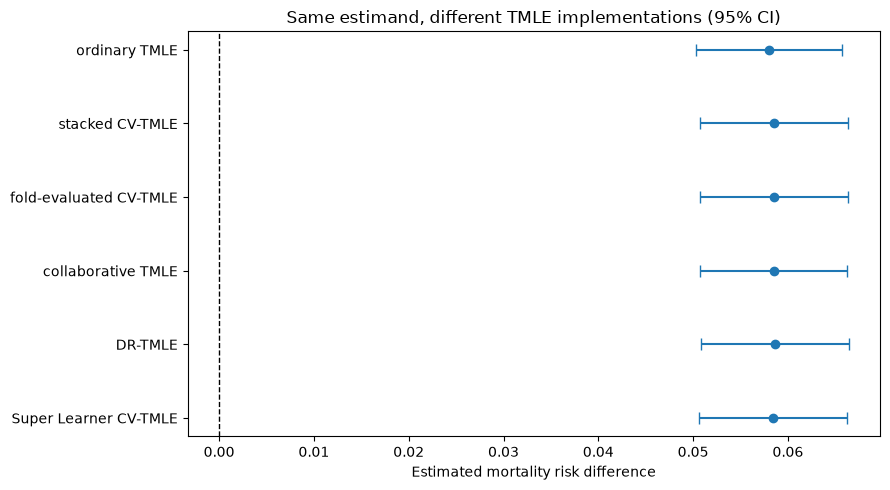

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_data = comparison.dropna(subset=["std_error"]).reset_index(drop=True)
y = np.arange(len(plot_data))
xerr = np.vstack(
    [
        plot_data["estimate"] - plot_data["ci_low"],
        plot_data["ci_high"] - plot_data["estimate"],
    ]
)
ax.errorbar(plot_data["estimate"], y, xerr=xerr, fmt="o", capsize=4)
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_yticks(y, plot_data["method"])
ax.set_xlabel("Estimated mortality risk difference")
ax.set_title("Same estimand, different TMLE implementations (95% CI)")
ax.invert_yaxis()
fig.tight_layout()

Agreement across estimators is reassuring about numerical stability, but it does not prove identification. Similar estimates can share the same unmeasured-confounding bias. Meaningful differences can also be informative: IPW is most exposed to extreme propensity estimates, while flexible nuisance learning can change both the initial outcome regression and the clever covariate.

## 7. Ask the question on more than one scale

A risk difference is not the only useful summary. `cleverly` makes the estimand a typed object, so we can state whether we want counterfactual risks, effects among exposed or unexposed children, a risk or odds ratio, or a population-attributable measure. Each line below is a separate causal question fit with the same stacked CV-TMLE configuration.

ATT and ATC change the target population. Risk and odds ratios change the contrast scale. PAR and PAF compare the observed population risk with the counterfactual risk under the reference exposure. These are not interchangeable restatements.

In [12]:
estimands = {
    "counterfactual risk": CounterfactualMean(),
    "ATT": ATT(reference=0),
    "ATC": ATC(reference=0),
    "risk ratio": RiskRatio(reference=0),
    "odds ratio": OddsRatio(reference=0),
    "population attributable risk": PopulationAttributableRisk(reference=0),
    "population attributable fraction": PopulationAttributableFraction(reference=0),
}
scale_rows = []
scale_results = {}
for question, estimand in estimands.items():
    fitted = point_study.estimate(estimand, method=methods["stacked CV-TMLE"])
    scale_results[question] = fitted
    for parameter, estimate in fitted.estimates.items():
        scale_rows.append(
            {
                "question": question,
                "parameter": parameter,
                "estimate": estimate.psi,
                "std_error": estimate.std_error,
                "ci_low": estimate.ci[0],
                "ci_high": estimate.ci[1],
            }
        )
effect_scales = pd.DataFrame(scale_rows)
effect_scales

,question,parameter,estimate,std_error,ci_low,ci_high
0,counterfactual risk,ey[0],0.0045,0.0009,0.0027,0.0064
1,counterfactual risk,ey[1],0.0630,0.0039,0.0554,0.0706
2,ATT,att,0.0610,0.0041,0.0530,0.0690
3,ATC,atc,0.0558,0.0041,0.0478,0.0639
4,risk ratio,rr,13.9248,0.2151,9.1355,21.2249
5,odds ratio,or,14.7942,0.2172,9.6655,22.6444
6,population attributable risk,par,0.0314,0.0021,0.0272,0.0356
7,population attributable fraction,paf,0.8740,0.0255,0.8239,0.9241


## 8. Diagnose before interpreting

A confidence interval is conditional on identification and nuisance-rate conditions. It does not diagnose them. Every cleverly result retains the fitted artifacts needed for support, nuisance, score-equation, and sensitivity checks.

- The **support report** asks whether treatment probabilities approach the truncation bounds or weights concentrate on a few observations.
- The **nuisance report** summarizes predictive performance and, for Super Learners, library weights.
- The **score report** checks that targeting solved the intended empirical efficient-score equations.
- **Omitted-variable sensitivity** asks how strong residual associations with treatment and outcome would need to be to move the ATE. It quantifies a scenario; it does not discover the missing variable.

In [13]:
print(flexible_result.diagnostics.run_all().summary())
print()
print(flexible_result.validate().summary())

diagnostic       status          detail                                                               
---------------  --------------  ---------------------------------------------------------------------
support          passed          no material support warning in the stored diagnostic                 
nuisance_models  passed          completed from stored fitted artifacts                               
score_equations  passed          completed from stored fitted artifacts                               
refute           unavailable     not run by default because it refits models; pass include_refits=True
stagewise        not_applicable  a point-treatment fit has no sequential nodes                        

Validation: PASS
----------------
check            status  detail                                                            
---------------  ------  ------------------------------------------------------------------
score_equations  passed  all 2 stored score checks converged

In [14]:
positivity = flexible_result.sensitivity.positivity()
omitted = flexible_result.sensitivity.omitted_variable("ate", cf_y=0.05, cf_d=0.05)
print(positivity.summary())
print()
print(omitted.summary())

Positivity / overlap diagnostics
--------------------------------
n = 12000; propensity truncated to [0.004859, 0.9951]

g(W) quantile  0%      1%      5%      25%     50%     75%     95%     99%     100%  
-------------  ------  ------  ------  ------  ------  ------  ------  ------  ------
overall        0.2868  0.3494  0.3855  0.4375  0.4898  0.5878  0.7005  0.7719  0.9258
treated        0.2999  0.3550  0.3921  0.4494  0.5115  0.6152  0.7178  0.7893  0.9258
control        0.2868  0.3460  0.3821  0.4284  0.4707  0.5482  0.6725  0.7474  0.8745

arm      n     effective n  ESS / n  top 1% weight  top 5% weight
-------  ----  -----------  -------  -------------  -------------
treated  6174  5955.1       0.965    0.015          0.070        
control  5826  5493.6       0.943    0.023          0.088        

threshold  P(g < t)  P(g > 1-t)
---------  --------  ----------
0.01       0.0000    0.0000    
0.025      0.0000    0.0000    
0.05       0.0000    0.0000    
0.1        0.0000    0.

### What we learned from the point-treatment analysis

The sequence matters more than any single estimate:

1. The crude contrast answered an associational question.
2. Identification converted the scientific claim into an observed-data functional and exposed its assumptions.
3. G-computation and IPW showed the two nuisance-model routes.
4. TMLE combined them, targeted the parameter, and supplied clustered influence-curve inference.
5. Cross-fitting separated nuisance training from evaluation; C-TMLE and DR-TMLE changed how nuisance bias is handled.
6. Diagnostics checked observable implications, while sensitivity analysis probed an unobservable failure mode.

None of steps 3–6 repairs an implausible DAG, an ill-defined intervention, or unmeasured confounding. Statistical sophistication comes after a defensible causal question.

## 9. A pedagogical longitudinal extension

The original CEVAE benchmark is not longitudinal. To demonstrate LTMLE without pretending otherwise, we now formulate a **new, illustrative prenatal-care question** from time-ordered fields in the same records:

- $A_1$: prenatal care began in the first trimester (`mpre5 == 1`);
- $L_2$: pregnancy-associated hypertension, a time-varying risk marker observed before the second care summary;
- $A_2$: higher prenatal-visit intensity (`nprevistq >= 3`); and
- $Y$: mortality by age three.

We compare the static regimes `always` $(1,1)$ and `never` $(0,0)$. This operationalization is intentionally simple and should not be read as a validated clinical intervention. In particular, visit totals depend on gestational duration and care access, treatment versions are heterogeneous, and complete-case restriction adds a selection assumption. Its purpose is to show the data structure and sequential identifying logic.

In [15]:
longitudinal_data = twins.dropna(subset=["mpre5", "nprevistq", "phyper"]).copy()
longitudinal_data["early_prenatal_care"] = (longitudinal_data["mpre5"] == 1).astype(int)
longitudinal_data["pregnancy_hypertension"] = longitudinal_data["phyper"].astype(int)
longitudinal_data["higher_visit_intensity"] = (longitudinal_data["nprevistq"] >= 3).astype(int)

LONG_BASELINE = (
    "mager8",
    "meduc6",
    "mrace",
    "dmar",
    "mplbir_reg",
    "data_year",
    "diabetes",
    "chyper",
    "tobacco",
    "alcohol",
    "birth_order",
)
for column in LONG_BASELINE:
    longitudinal_data[column] = (
        longitudinal_data[column].fillna(longitudinal_data[column].median()).astype(float)
    )

long_summary = (
    longitudinal_data[
        ["early_prenatal_care", "pregnancy_hypertension", "higher_visit_intensity", "mortality_3y"]
    ]
    .mean()
    .to_frame("prevalence")
)
long_summary.loc["children retained", "prevalence"] = len(longitudinal_data)
long_summary

,prevalence
early_prenatal_care,0.7965
pregnancy_hypertension,0.0656
higher_visit_intensity,0.3560
mortality_3y,0.0341
children retained,10764.0000


Longitudinal exchangeability is sequential: at each treatment node, the future counterfactual outcome must be independent of that treatment given the observed past. At the second node, history includes baseline, $A_1$, and $L_2$. Positivity must also hold for each regime at each observed history. LTMLE works backward through these histories, targeting a sequence of outcome regressions with cumulative treatment probabilities.

In [16]:
long_study = CausalStudy(
    longitudinal_data,
    design=LongitudinalTreatment(
        outcome="mortality_3y",
        treatment=("early_prenatal_care", "higher_visit_intensity"),
        baseline=LONG_BASELINE,
        time_varying=((), ("pregnancy_hypertension",)),
        cluster="pair_id",
        outcome_family="binomial",
    ),
)
regime_effect = long_study.identify(RegimeContrast({"always": 1, "never": 0}, reference="never"))
print(regime_effect.summary())
pd.DataFrame([vars(item) for item in regime_effect.available_methods()])

contrast of each regime against the reference
identified by explicit-adjustment: sequential g-formula under the declared treatment regimen
adjustment/history: ['mager8', 'meduc6', 'mrace', 'dmar', 'mplbir_reg', 'data_year', 'diabetes', 'chyper', 'tobacco', 'alcohol', 'birth_order']
assumptions:
  - consistency and no interference
  - sequential exchangeability given the recorded history at every node
  - sequential positivity for treatment and remaining under observation


,name,available,reason
0,tmle,True,NaN
1,collaborative_tmle,False,no collaborative score is evidenced for this f...
2,drtmle,False,no reduced-dimension correction is evidenced f...
3,riesz_tmle,False,the direct-Riesz engine and intervention-state...
4,ep,False,EP requires a conditional-contrast estimand an...


In [17]:
long_result = regime_effect.estimate(
    outcome_learner=LinearRegression(),
    pseudo_learner=LinearRegression(),
    treatment_learner=LogisticRegression(max_iter=3_000),
    n_folds=3,
    learner_folds=3,
    simultaneous=False,
    random_state=SEED,
)
print(long_result.summary())
print()
print(long_result.diagnostics.run_all().summary())

Longitudinal TMLE (2 time points, n = 10764)

parameter                     estimate  std. error  95% CI              p-value
----------------------------  --------  ----------  ------------------  -------
ate_regimen[always vs never]  -0.0248   0.0057      [-0.0360, -0.0135]  <1e-4  

  time points: 2
  outcome family: binomial
  regimens: always=(1/1), never=(0/0)
  reference: never
  cross-fitting: 3 fold(s)
  g_bounds: fixed [0.01, 1] on each cumulative treatment-and-censoring probability (package default; R ltmle-compatible heuristic -- inspect truncation diagnostics)
  confidence level: 95%
  random_state: 2026
  causal estimand: contrast of each regime against the reference
  identification: explicit-adjustment; sequential g-formula under the declared treatment regimen
  identification assumptions: consistency and no interference; sequential exchangeability given the recorded history at every node; sequential positivity for treatment and remaining under observation
  clusters = 

The longitudinal estimate answers a different question from the low-birth-weight ATE. Its treatment is a two-node strategy, its adjustment set is a history rather than one baseline vector, and its clever covariates use cumulative treatment probabilities. C-TMLE and DR-TMLE correctly appear unavailable here because cleverly has no longitudinal derivation for those variants. An unavailable method is a scientific boundary, not an invitation to substitute a nearby estimator silently.

## 10. Why other cleverly methods are not used here

Using every API on one dataset would make the analysis less honest. The following implemented families need a different scientific question or data structure:

| family | why it is not appropriate for this worked question |
| --- | --- |
| continuous modified treatment policies | birth weight is not a manipulable continuous dose with a defensible shift intervention here |
| incremental propensity interventions | these tilt a treatment-assignment mechanism; our primary question is a static binary contrast |
| controlled direct effects | a mediator intervention and additional identification assumptions would need to be defended |
| missing-outcome TMLE | the published mortality outcome has no missing values |
| survival and competing-risk LTMLE | only a single three-year mortality indicator is available, not event-time nodes or competing causes |
| marginal structural model projections | two static regimes suffice for the teaching contrast; a projection requires a prespecified regimen set and working model |
| multi-arm TMLE | the exposure was deliberately defined as binary |

A good analysis uses the most complex estimator justified by its question and observed data—not the largest number of methods available.

## 11. Reproducibility record

A production report should also record the exact notebook, data commit, software environment, estimand, adjustment/history variables, learner libraries, fold plan, treatment bounds, missing-data handling, clustering, and all diagnostics inspected. `cleverly` results retain normalized method configuration and provenance; saving a result uses joblib and should only be loaded from a trusted source.

In [18]:
pd.Series(
    {
        "python": platform.python_version(),
        "cleverly": cleverly.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit-learn": sklearn.__version__,
        "CEVAE data commit": COMMIT,
        "seed": SEED,
        "sampled pairs": N_PAIRS,
    },
    name="value",
)

python                                                 3.13.7
cleverly                                                0.1.0
numpy                                                   2.4.6
pandas                                                  3.0.5
scikit-learn                                            1.9.0
CEVAE data commit    9081f863e24ce21bd34c8d6a41bf0edc7d1b65dd
seed                                                     2026
sampled pairs                                            6000
Name: value, dtype: object